<b>Cancer Classification</b>

<i>In this project, I try to build an Artificial Neural Network which can train itself to classify the type of cancer based on several factors</i>

1.<u>Data preprocessing</u>

<i>Importing modules</i>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

<i>Importing dataset</i>

In [3]:
dataset = pd.read_csv(r"C:\Users\Abhijyot Singh Roda\Desktop\Coding Stuff\Python\Projects\Not so random projects\ML Projects\Datasets\cancer_classification.csv",
encoding="latin1")

<i>Information about the dataset</i>

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

<i>First 5 rows</i>

In [5]:
dataset.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


<i>Last 5 rows</i>

In [6]:
dataset.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


<i>Removing unnecessary columns using ANOVA</i>

In [7]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

numeric_col=dataset.select_dtypes(["int64","float64"]).columns

for col in numeric_col:
    if col!="car_purchase_amount":
        model=ols(f"benign_0__mal_1~Q('{col}')",data=dataset).fit()
        anova=sm.stats.anova_lm(model,typ=2)
        print(f"ANOVA result for {col}:")
        print(anova,"\n")

ANOVA result for mean radius:
                     sum_sq     df           F        PR(>F)
Q('mean radius')  70.887793    1.0  646.981021  8.465941e-96
Residual          62.124509  567.0         NaN           NaN 

ANOVA result for mean texture:
                       sum_sq     df           F        PR(>F)
Q('mean texture')   22.928505    1.0  118.096059  4.058636e-25
Residual           110.083797  567.0         NaN           NaN 

ANOVA result for mean perimeter:
                        sum_sq     df           F         PR(>F)
Q('mean perimeter')  73.357286    1.0  697.235272  8.436251e-101
Residual             59.655016  567.0         NaN            NaN 

ANOVA result for mean area:
                   sum_sq     df           F        PR(>F)
Q('mean area')  66.859709    1.0  573.060747  4.734564e-88
Residual        66.152594  567.0         NaN           NaN 

ANOVA result for mean smoothness:
                          sum_sq     df          F        PR(>F)
Q('mean smoothness')   17.1

Removing columns

In [8]:
dataset=dataset.drop(["mean fractal dimension","texture error","smoothness error","symmetry error","fractal dimension error"],axis="columns")

- Updated dataset

In [9]:
dataset.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,radius error,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,1.0950,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.5435,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.7456,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.4956,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.7572,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


<i>Understanding missing values</i>

In [10]:
print("Number of missing values:")
print(dataset.isnull().sum())

Number of missing values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
radius error               0
perimeter error            0
area error                 0
compactness error          0
concavity error            0
concave points error       0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
benign_0__mal_1            0
dtype: int64


<i>Understanding data distribution</i>

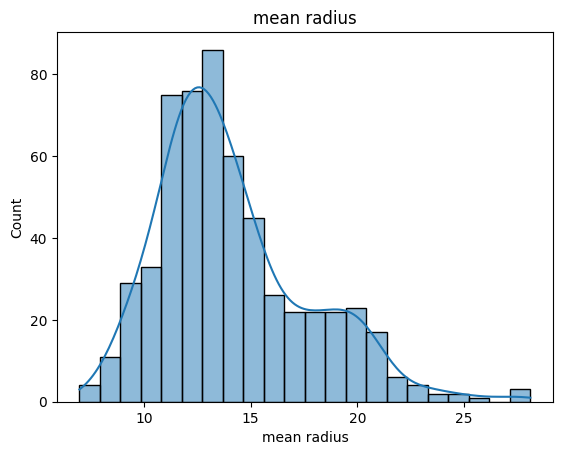

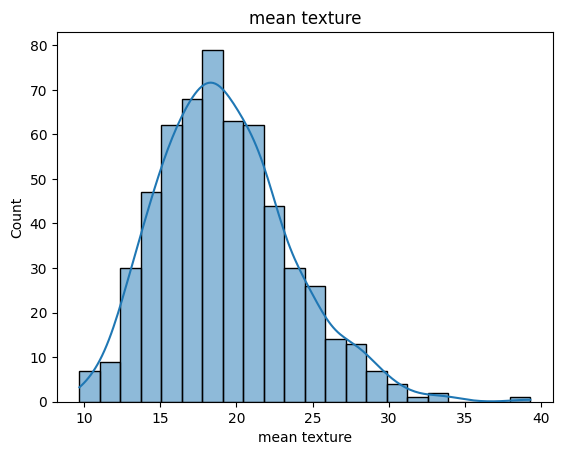

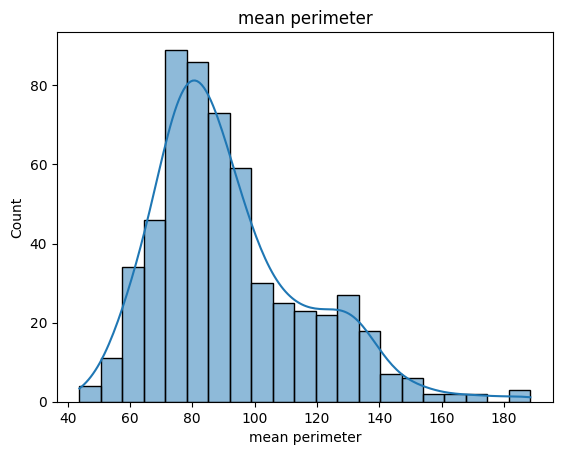

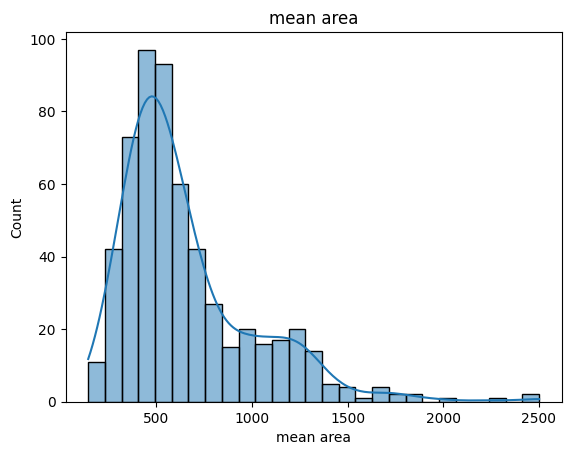

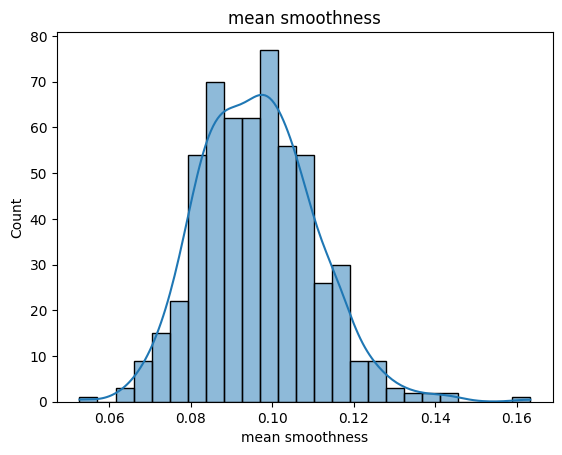

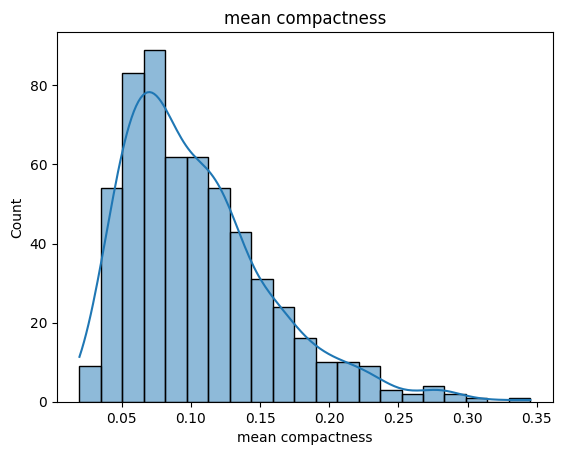

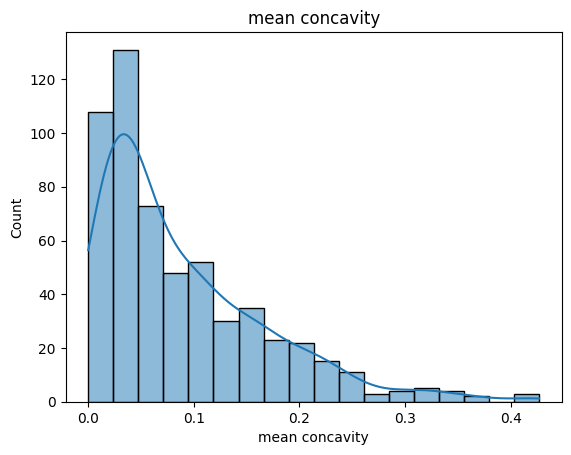

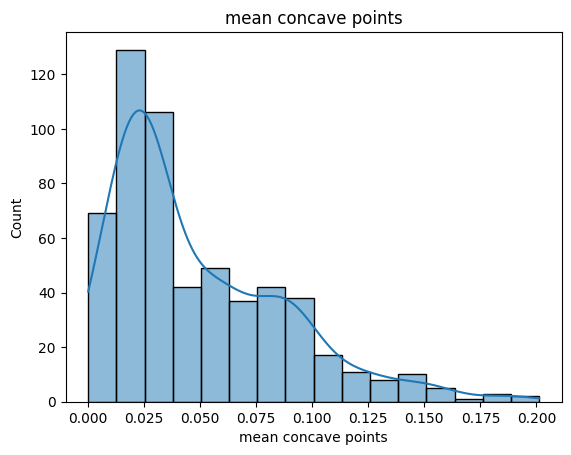

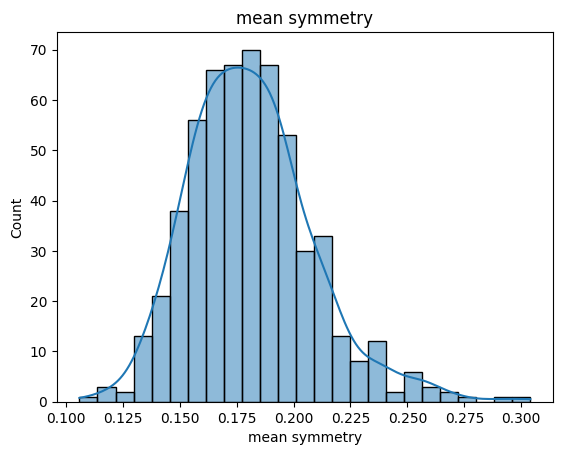

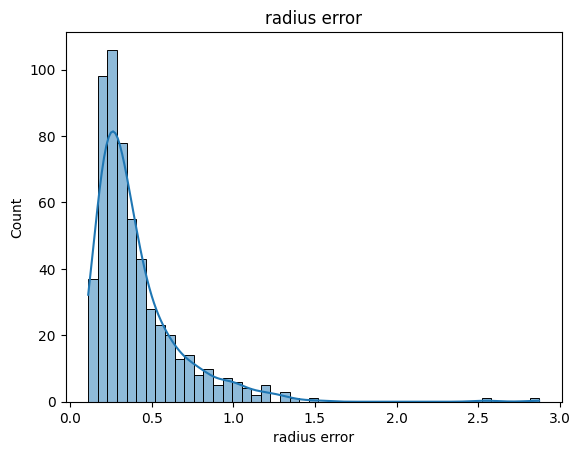

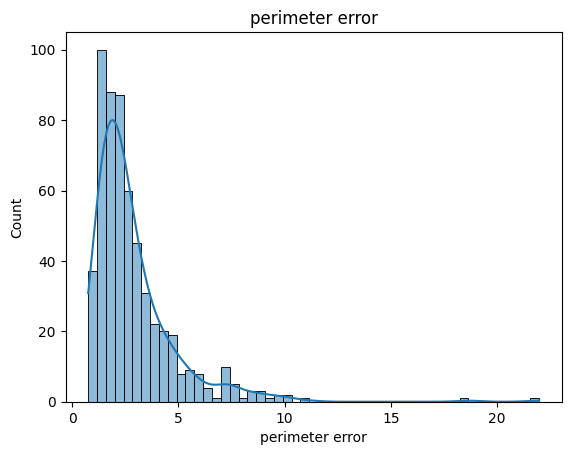

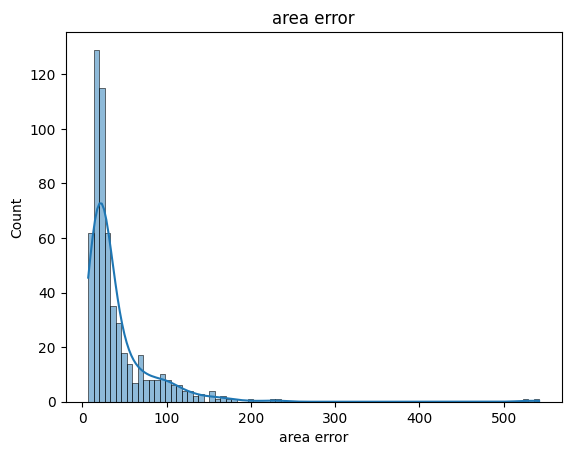

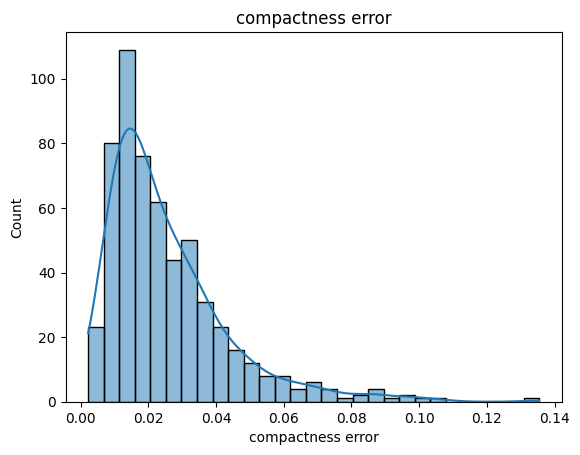

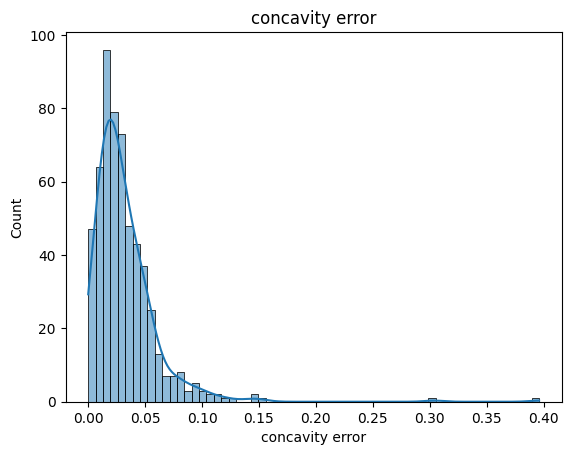

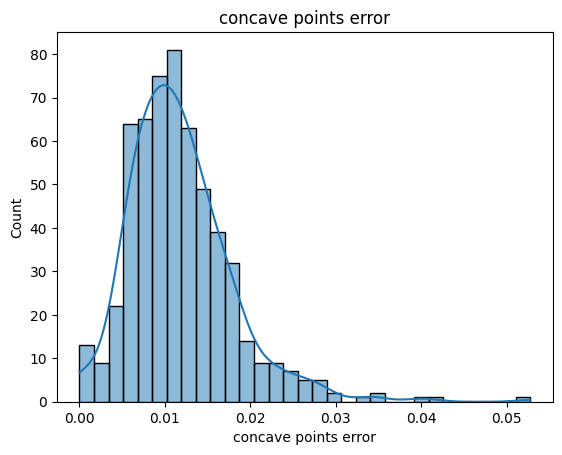

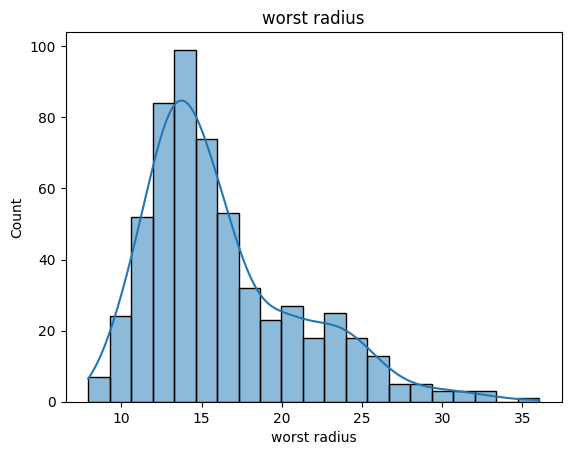

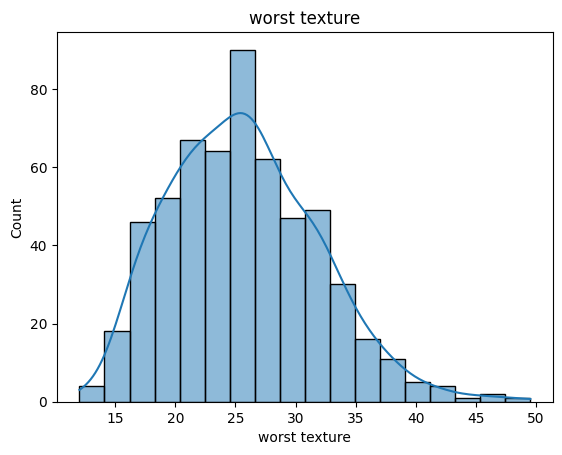

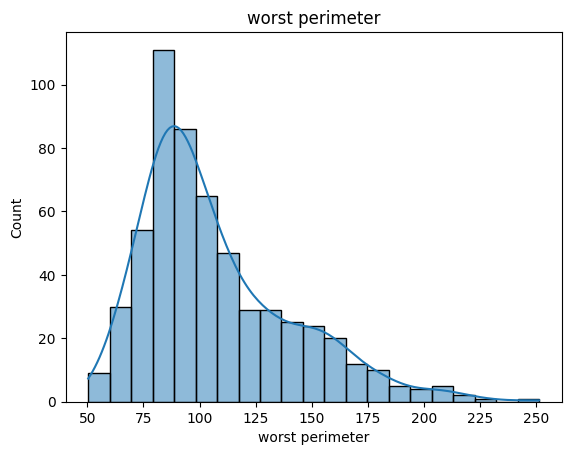

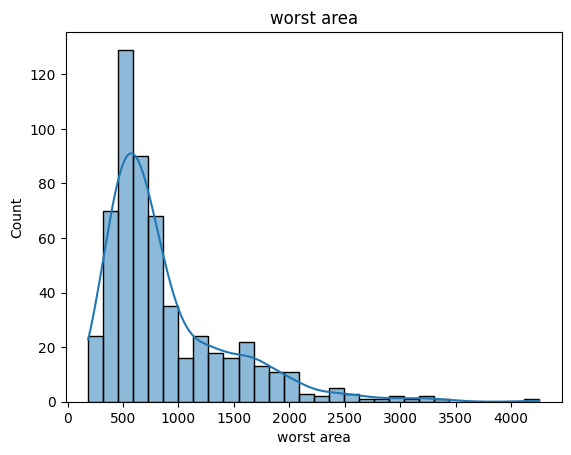

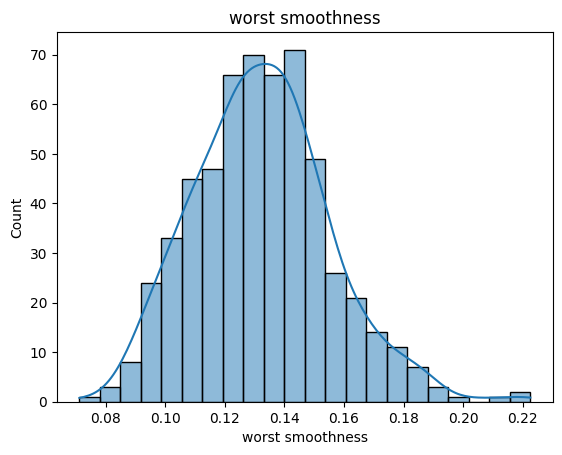

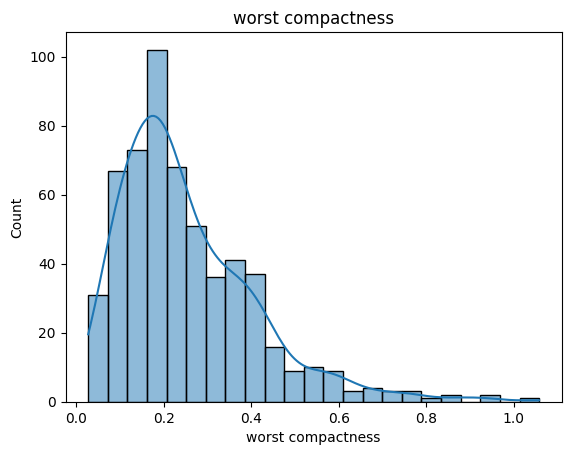

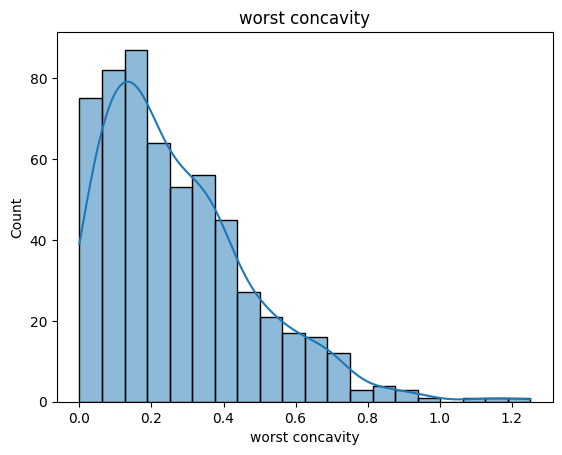

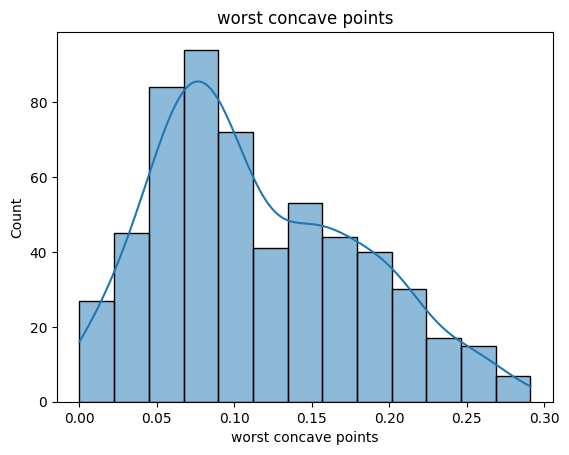

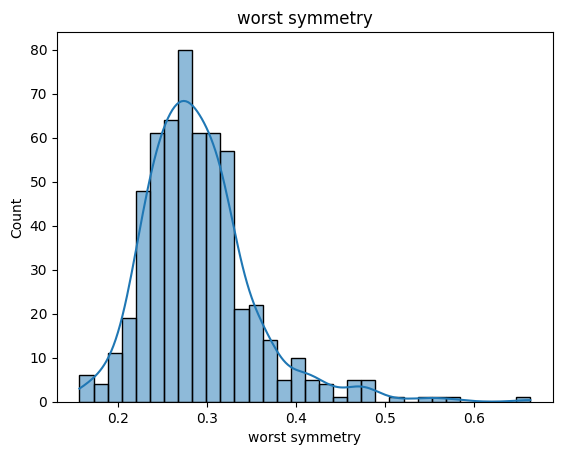

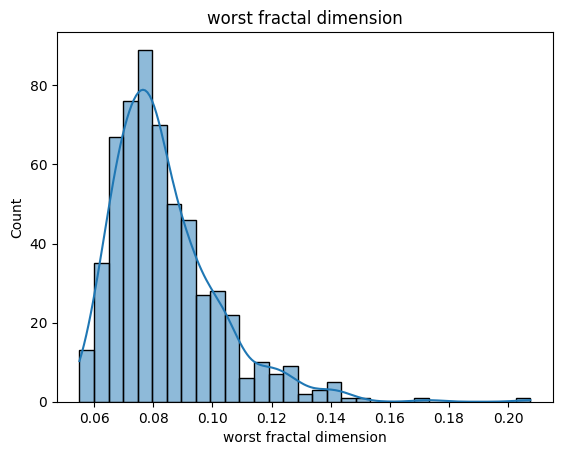

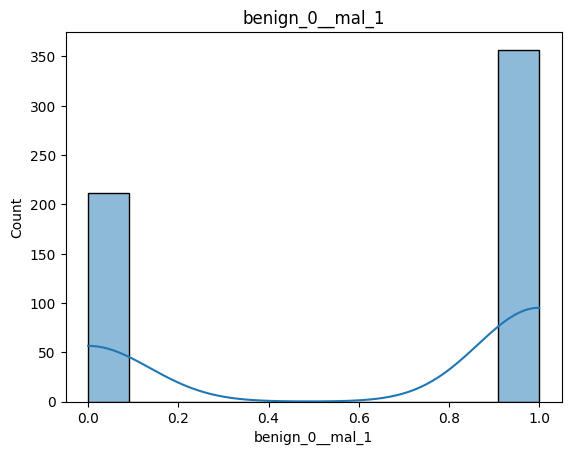

In [11]:
numeric_col=dataset.select_dtypes(["int64","float64"]).columns

for col in numeric_col:
    plt.title(col)
    sns.histplot(dataset[col],kde=True)
    plt.show()

<i>Understanding outliers</i>

- Very small amount of outliers, therefore no need to cap them

In [12]:
for col in numeric_col:
    if col!="gender":
        q1=dataset[col].quantile(0.25)
        q3=dataset[col].quantile(0.75)
        iqr=q3-q1
        lower=q1-1.5*iqr
        upper=q3+1.5*iqr
        outliers=((dataset[col]<lower)|(dataset[col]>upper))
        print(f"Percentage number of outliers in {col}: {outliers.sum()/len(dataset)*100}%")

Percentage number of outliers in mean radius: 2.460456942003515%
Percentage number of outliers in mean texture: 1.2302284710017575%
Percentage number of outliers in mean perimeter: 2.2847100175746924%
Percentage number of outliers in mean area: 4.393673110720562%
Percentage number of outliers in mean smoothness: 1.054481546572935%
Percentage number of outliers in mean compactness: 2.8119507908611596%
Percentage number of outliers in mean concavity: 3.163444639718805%
Percentage number of outliers in mean concave points: 1.7574692442882252%
Percentage number of outliers in mean symmetry: 2.6362038664323375%
Percentage number of outliers in radius error: 6.6783831282952555%
Percentage number of outliers in perimeter error: 6.6783831282952555%
Percentage number of outliers in area error: 11.423550087873462%
Percentage number of outliers in compactness error: 4.92091388400703%
Percentage number of outliers in concavity error: 3.8664323374340945%
Percentage number of outliers in concave poi

<i>Splitting the dataset into Matrix of Features (X) and Dependent Variable Vector (y)</i>

In [13]:
X=dataset.iloc[:,:-1].values
y=dataset.iloc[:,-1].values

<i>Splitting the dataset into training and test set</i>

In [14]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

<i>Feature scaling</i>

In [15]:
from sklearn.preprocessing import StandardScaler

sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

2.<u>ANN building</u>

<i>Initialising ANN</i>

In [16]:
ann=tf.keras.models.Sequential()

<i>Adding the first input and hidden layer</i>

In [17]:
ann.add(tf.keras.layers.Dense(units=26,activation="relu"))

<i>Adding 4 more hidden layers</i>

In [18]:
for i in range(5):
    ann.add(tf.keras.layers.Dense(units=26,activation="relu"))

<i>Adding the output layer</i>

In [19]:
ann.add(tf.keras.layers.Dense(units=1,activation="sigmoid"))

<i>Compiling ANN</i>

In [20]:
ann.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

<i>Training ANN</i>

In [21]:
ann.fit(X_train,y_train,batch_size=32,epochs=25)

Epoch 1/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4285 - loss: 0.7277
Epoch 2/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9027 - loss: 0.5798 
Epoch 3/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 961us/step - accuracy: 0.9341 - loss: 0.3982
Epoch 4/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - accuracy: 0.9184 - loss: 0.2418
Epoch 5/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 916us/step - accuracy: 0.9610 - loss: 0.1204
Epoch 6/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9614 - loss: 0.1248 
Epoch 7/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 900us/step - accuracy: 0.9675 - loss: 0.0857
Epoch 8/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 933us/step - accuracy: 0.9786 - loss: 0.0631
Epoch 9/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 887us/step - accuracy: 0.9792 - loss: 0.0577
Epoch 10/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 996us/step - accuracy: 0.9734 - loss: 0.0658
Epoch 11/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step - accuracy: 0.9861 - loss: 0.0504
Epoch 12/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step - a

<i>Predicting the values for training and test set</i>

In [22]:
y_pred_train=ann.predict(X_train)
y_pred_test=ann.predict(X_test)

y_pred_train=(y_pred_train>0.5)
y_pred_test=(y_pred_test>0.5)

print("For the training set:")
print("[Actual_Outcome Predicted_Outcome]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train.reshape(len(y_pred_train),1)),axis=1))
print()

print("For the test set:")
print("[Actual_Outcome Predicted_Outcome]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test.reshape(len(y_pred_test),1)),axis=1))

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
For the training set:
[Actual_Outcome Predicted_Outcome]
[[1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 

<i>Accuracy of the model</i>

Accuracy for the training set: 99.78021978021978%
Accuracy for the test set: 97.36842105263158%

Confusion matrix for the training set:


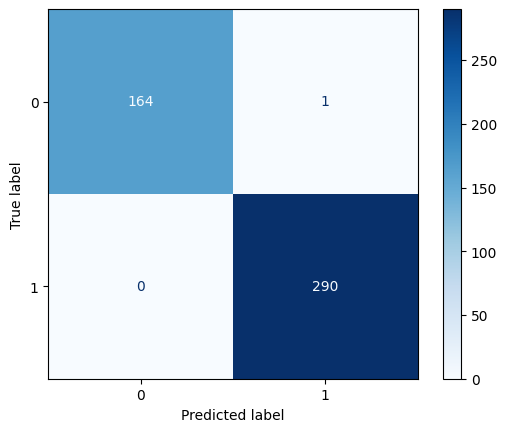


Confusion matrix for the test set:


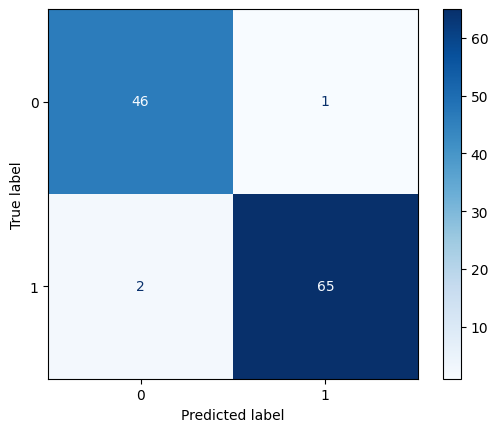

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

con_mat1=confusion_matrix(y_train,y_pred_train)
con_mat2=confusion_matrix(y_test,y_pred_test)

disp1=ConfusionMatrixDisplay(confusion_matrix=con_mat1)
disp2=ConfusionMatrixDisplay(confusion_matrix=con_mat2)

print(f"Accuracy for the training set: {accuracy_score(y_train,y_pred_train)*100}%")
print(f"Accuracy for the test set: {accuracy_score(y_test,y_pred_test)*100}%")
print()

print("Confusion matrix for the training set:")
disp1.plot(cmap=plt.cm.Blues)
plt.show()
print()

print("Confusion matrix for the test set:")
disp2.plot(cmap=plt.cm.Blues)
plt.show()

3.<u>Result</u>

## 3. Results

### Model Architecture
| Layer | Type | Units | Activation |
|---|---|---|---|
| Input + Hidden 1 | Dense | 26 | ReLU |
| Hidden 2–5 | Dense (×4) | 26 | ReLU |
| Output | Dense | 1 | Sigmoid |

- **Optimizer:** Adam
- **Loss function:** Binary Crossentropy
- **Epochs:** 25 | **Batch size:** 32

### Dataset Summary
- **569 samples**, 25 features after removing 5 low-significance columns (`mean fractal dimension`, `texture error`, `smoothness error`, `symmetry error`, `fractal dimension error`) based on ANOVA p-values
- No missing values
- Train/Test split: 80% / 20%, features scaled with `StandardScaler`

### Performance

| Metric | Training Set | Test Set |
|---|---|---|
| **Accuracy** | 99.78% | 97.36% |

Confusion matrices for both sets are plotted above using `ConfusionMatrixDisplay`.

### Key Takeaways
- The ANN achieves **~98% accuracy on unseen test data**, indicating strong generalization with minimal overfitting (only a ~1.5 percentage-point gap between train and test accuracy).
- Feature selection via ANOVA before training helped reduce dimensionality without hurting performance.
- Given the high stakes of cancer classification, false negatives (malignant cases predicted as benign) from the confusion matrix should be examined closely — accuracy alone can be misleading on any class imbalance.

4.<u>Model deployment</u>

In [25]:
import pickle as pk

ann.save("ANN.keras")
    
with open(r"scaler.pk","wb") as file:
    pk.dump(sc,file)